# PA1 — Task 2, final: the `grad_clip = 0.0` pipeline

**Nothing to upload.** Cell A3 patches one file in your repo so the evaluation script can read and
write folders you name, instead of the hardcoded `runs/` and `final/`.

**Nothing is moved, renamed or deleted.** Two pipelines simply live side by side:

| Folder | What it is | This notebook |
|---|---|---|
| `task2/results/runs_clip1.0` | runs trained **with** clipping | read-only (one comparison table) |
| `task2/results/final` | their tables and figures | **never written** |
| `task2/results/runs_clip0.0` | the six runs trained **without** clipping | read; trains only a run that is missing |
| `task2/results/final_clip0.0` | this pipeline's tables and figures | created here |

**Why this pipeline is the one to report.** `grad_clip: 0.0` is exactly the optimiser the handout
specifies. Clipping was an addition of mine; it moved the baseline by about four points on Sketch and
did not stop DANN or CDAN from diverging, so those runs stay as an appendix.

Repository at **My Drive/PA1**, runtime **T4 GPU**.

## Part A — setup (run every session)

In [1]:
# A1. GPU check.
import subprocess
out = subprocess.run('nvidia-smi --query-gpu=name,memory.total --format=csv,noheader',
                     shell=True, capture_output=True, text=True).stdout.strip()
print(f'GPU: {out}' if out else 'NO GPU -- Runtime > Change runtime type > T4 GPU, then re-run.')

GPU: Tesla T4, 15360 MiB


In [2]:
# A2. Mount Drive and move into the repository.
from google.colab import drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive'
REPO = f'{DRIVE}/PA1'          # <- change if your repo folder has another name
%cd {REPO}

Mounted at /content/drive
/content/drive/MyDrive/PA1


In [3]:
# A3. Patch evaluate_final.py so its input and output folders can be chosen. Safe to re-run: it
# detects a copy that is already patched and leaves it alone.
import pathlib
p = pathlib.Path('task2/evaluate_final.py'); s = p.read_text()
if 'environ.get("RUNS_DIR"' in s:
    MODE = 'env';  print('Already patched (environment-variable version).')
elif '--runs-dir' in s:
    MODE = 'cli';  print('Already patched (command-line version).')
elif 'Path(resolve("task2/results/runs"))' in s:
    s = s.replace('Path(resolve("task2/results/runs"))',
                  'Path(resolve(os.environ.get("RUNS_DIR", "task2/results/runs")))')
    s = s.replace('Path(resolve("task2/results/final"))',
                  'Path(resolve(os.environ.get("OUT_DIR", "task2/results/final")))')
    if '\nimport os' not in s:
        s = s.replace('import argparse', 'import argparse\nimport os', 1)
    p.write_text(s); MODE = 'env'
    print('Patched: RUNS_DIR / OUT_DIR environment variables now override the default folders.')
else:
    raise RuntimeError('Unexpected evaluate_final.py -- send it to Claude before continuing.')
print('MODE =', MODE)
!grep -n "RUNS_DIR\|runs-dir" task2/evaluate_final.py | head

Patched: RUNS_DIR / OUT_DIR environment variables now override the default folders.
MODE = env
62:    cfg = load_json(Path(resolve(os.environ.get("RUNS_DIR", "task2/results/runs"))) / "source_only" / "config_resolved.json")
64:    runs_dir = Path(resolve(os.environ.get("RUNS_DIR", "task2/results/runs")))


In [4]:
# A4. The config must match the runs in runs_clip0.0. Task 3 inherits this value, so it also fixes
# which pipeline Task 3 will be compared against.
!sed -i 's/^grad_clip: .*/grad_clip: 0.0          # handout protocol: no gradient clipping/' task2/configs/base.yaml
!grep '^grad_clip' task2/configs/base.yaml

grad_clip: 0.0          # handout protocol: no gradient clipping


In [5]:
# A5. Helpers. This notebook reads and writes ONLY these two folders.
import subprocess, json, math, glob, os
import pandas as pd
import matplotlib.pyplot as plt

RUNS_DIR = 'task2/results/runs_clip0.0'     # the six runs trained without gradient clipping
OUT_DIR  = 'task2/results/final_clip0.0'    # tables and figures for this pipeline
CHANCE_LOSS = math.log(7)                   # 1.946 = cross-entropy of uniform guessing over 7 classes

def run(cmd):
    print('$', cmd, flush=True)
    p = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        print(line, end='')
    if p.wait() != 0:
        raise RuntimeError(f'Command failed (exit code {p.returncode}): {cmd}')

def eval_cmd(study=None):
    """Build the evaluate_final command for THIS pipeline's folders (see cell A3 for MODE)."""
    s = f' --study {study}' if study else ''
    if MODE == 'env':
        return f'RUNS_DIR={RUNS_DIR} OUT_DIR={OUT_DIR} python -m task2.evaluate_final{s}'
    return f'python -m task2.evaluate_final{s} --runs-dir {RUNS_DIR} --out-dir {OUT_DIR}'

def report(run_name):
    """Health summary + curves for one run. Checks, in order: classification loss (must end far below
    1.95), the alignment or domain loss, discriminator accuracy, and the gradient norm."""
    d = f'{RUNS_DIR}/{run_name}'
    s, hist = json.load(open(f'{d}/summary.json')), json.load(open(f'{d}/history.json'))
    clip = float(s['config'].get('grad_clip', 0.0))
    ep = [h['epoch'] for h in hist]; f1 = [h['val_mean_macro_f1'] for h in hist]
    cls = [h['loss_cls'] for h in hist]; gn = [h.get('grad_norm', float('nan')) for h in hist]
    print(f'\n=== {run_name} ===')
    print(f'  grad_clip               : {clip}' + ('   (handout protocol: no clipping)' if clip == 0 else ''))
    print(f'  epochs run              : {s["epochs_run"]} of {s["config"]["max_epochs"]}'
          f' ({"early stop" if s["epochs_run"] < s["config"]["max_epochs"] else "full budget"})')
    print(f'  best source-val macro-F1: {s["best_mean_macro_f1"]:.2f}  (epoch {ep[int(pd.Series(f1).idxmax())]} -- the saved checkpoint)')
    print(f'  classification loss     : {cls[0]:.3f} -> {cls[-1]:.3f}   (1.95 = chance)')
    for k, lab in [('loss_mmd', 'MMD alignment loss     '), ('loss_dom', 'domain loss            ')]:
        if k in hist[0]:
            print(f'  {lab} : {hist[0][k]:.3f} -> {hist[-1][k]:.3f}'
                  + ('   (0.69 = discriminator guessing)' if k == 'loss_dom' else '   (trend only: biased estimator)'))
    if 'disc_acc' in hist[0]:
        print(f'  discriminator accuracy  : {100*hist[0]["disc_acc"]:.1f}% -> {100*hist[-1]["disc_acc"]:.1f}%   (50% = confused)')
    print(f'  gradient norm           : max {max(gn):.3g}'
          + (f', clipped on {sum(g > clip for g in gn if g == g)}/{len(gn)} epochs' if clip else '  (no clipping applied)'))
    print('  VERDICT: ' + ('COLLAPSED -- never learned the classes; report as instability, not as the method.'
                           if min(cls) > 1.6 or s['best_mean_macro_f1'] < 50 else
                           'unstable -- learned, then diverged; the saved checkpoint predates the blow-up.'
                           if cls[-1] > 1.6 or s['best_mean_macro_f1'] < 80 or max(gn) > 1e3 else 'looks healthy.'))
    panels = [('loss_cls', 'classification loss', CHANCE_LOSS)]
    if 'loss_mmd' in hist[0]: panels.append(('loss_mmd', 'MMD alignment loss', None))
    if 'loss_dom' in hist[0]: panels.append(('loss_dom', 'domain loss', math.log(2)))
    if 'disc_acc' in hist[0]: panels.append(('disc_acc', 'discriminator accuracy', 0.5))
    panels += [('val_mean_macro_f1', 'mean source-val macro-F1', None), ('grad_norm', 'gradient norm', None)]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 2.6))
    for ax, (key, title, line) in zip(axes, panels):
        v = [h.get(key, float('nan')) for h in hist]
        ax.plot(ep, v, marker='.')
        if key == 'grad_norm' and max(v) > 100: ax.set_yscale('log')
        if line: ax.axhline(line, color='r', ls=':', lw=1)
        ax.set_title(f'{run_name}: {title}', fontsize=8); ax.set_xlabel('epoch'); ax.grid(alpha=.3)
    fig.tight_layout(); plt.show()

print('Helpers ready.')
print('  reads/writes :', RUNS_DIR, '->', OUT_DIR)
print('  never touched: task2/results/runs_clip1.0, task2/results/final')

Helpers ready.
  reads/writes : task2/results/runs_clip0.0 -> task2/results/final_clip0.0
  never touched: task2/results/runs_clip1.0, task2/results/final


In [6]:
# A6. Inventory: check each folder holds what its name says, before anything else runs.
for d in ['task2/results/runs_clip0.0', 'task2/results/runs_clip1.0']:
    if not os.path.isdir(d):
        print(f'{d}: MISSING\n'); continue
    rs = sorted(x for x in os.listdir(d) if os.path.isdir(f'{d}/{x}'))
    done = [r for r in rs if os.path.exists(f'{d}/{r}/summary.json')]
    clips = {json.load(open(f'{d}/{r}/summary.json'))['config'].get('grad_clip', 0.0) for r in done}
    f1 = {r: round(json.load(open(f'{d}/{r}/summary.json'))['best_mean_macro_f1'], 2) for r in done}
    print(f'{d}\n   {len(done)}/{len(rs)} finished | grad_clip={clips}\n   source-val F1: {f1}\n')
print('Expected: runs_clip0.0 -> grad_clip {0.0}, source_only 94.14  |  runs_clip1.0 -> {1.0}, 93.88')
print('If those are swapped, stop and check before running Part C.')

task2/results/runs_clip0.0
   6/6 finished | grad_clip={0.0}
   source-val F1: {'cdan': 88.75, 'dan': 95.02, 'dan_lambda0.1': 93.9, 'dan_lambda10': 5.07, 'dann': 35.04, 'source_only': 94.14}

task2/results/runs_clip1.0
   6/6 finished | grad_clip={1.0}
   source-val F1: {'cdan': 93.39, 'dan': 93.7, 'dan_lambda0.1': 94.01, 'dan_lambda10': 5.07, 'dann': 77.51, 'source_only': 93.88}

Expected: runs_clip0.0 -> grad_clip {0.0}, source_only 94.14  |  runs_clip1.0 -> {1.0}, 93.88
If those are swapped, stop and check before running Part C.


In [7]:
# A7. PACS on local disk, restored from your Drive backup, plus the fixed splits.
import shutil
PACS = '/content/data/PACS'
DRIVE_ZIP = f'{DRIVE}/datasets/PACS.zip'
EXPECTED = {'photo': 1670, 'art_painting': 2048, 'cartoon': 2344, 'sketch': 3929}
if not os.path.isdir(f'{PACS}/sketch'):
    assert os.path.exists(DRIVE_ZIP), 'No PACS backup in Drive -- re-run an earlier notebook cell A5 once.'
    print('Restoring PACS from Drive ...')
    run(f'unzip -q "{DRIVE_ZIP}" -d /content/data')
for d, n in EXPECTED.items():
    got = len([q for q in glob.glob(f'{PACS}/{d}/*/*') if q.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f'  {d:13s} {got:5d}  (expected {n})' + ('' if got == n else '   <-- MISMATCH'))
src = json.load(open('shared/splits/pacs_sources_seed6304.json'))['domains']
print('\nSplits reused unchanged:', {d: f"train {len(s['train'])}, val {len(s['val'])}" for d, s in src.items()})

Restoring PACS from Drive ...
$ unzip -q "/content/drive/MyDrive/datasets/PACS.zip" -d /content/data
  photo          1670  (expected 1670)
  art_painting   2048  (expected 2048)
  cartoon        2344  (expected 2344)
  sketch         3929  (expected 3929)

Splits reused unchanged: {'photo': 'train 1336, val 334', 'art_painting': 'train 1638, val 410', 'cartoon': 'train 1875, val 469'}


## Part B — the six runs

All six runs exist in `runs_clip0.0`, so **cell B1 is commented out** on purpose: the notebook you
commit to GitHub then shows exactly how each model was trained, without retraining anything if
someone runs it top to bottom.

- **B0** only defines the run list and the `train()` helper, and prints which runs exist. It trains nothing.
- **B1** is the training/reporting loop, commented out. Uncomment it to retrain a missing run or to
  reprint the health summaries and curves.
- **B2** reads the finished runs from disk and tabulates them. It trains nothing either.

In [8]:
# B0. Run list and trainer, pinned to RUNS_DIR.
STUDY = 'dan'
COMMON = f'--set data_root={PACS} results_dir={RUNS_DIR}'
RUN_LIST = [('source_only', 'source_only'), ('dan', 'dan'), ('dann', 'dann'), ('cdan', 'cdan'),
            ('study_dan_lambda0.1', 'dan_lambda0.1'), ('study_dan_lambda10', 'dan_lambda10')]

def train(config, run_name):
    if os.path.exists(f'{RUNS_DIR}/{run_name}/summary.json'):
        print(f'{run_name}: already finished -- skipping')
    else:
        run(f'python -m task2.train --config task2/configs/{config}.yaml {COMMON}')
    report(run_name)

for c, r in RUN_LIST:
    print(f'  {"done   " if os.path.exists(f"{RUNS_DIR}/{r}/summary.json") else "pending"}  {r}')

  done     source_only
  done     dan
  done     dann
  done     cdan
  done     dan_lambda0.1
  done     dan_lambda10


In [9]:
# B1. TRAINING (commented out -- all six runs are already in runs_clip0.0).
#
# Each run is one command; `train()` skips a run whose summary.json already exists and then prints
# its health summary and curves. Uncomment the two lines below to retrain a missing run, or to
# reprint the reports.
#
#     python -m task2.train --config task2/configs/source_only.yaml         --set data_root=... results_dir=...
#     python -m task2.train --config task2/configs/dan.yaml                 --set ...
#     python -m task2.train --config task2/configs/dann.yaml                --set ...
#     python -m task2.train --config task2/configs/cdan.yaml                --set ...
#     python -m task2.train --config task2/configs/study_dan_lambda0.1.yaml --set ...
#     python -m task2.train --config task2/configs/study_dan_lambda10.yaml  --set ...

# for c, r in RUN_LIST:
#     train(c, r)

print('Part B skipped: using the runs already in', RUNS_DIR)

Part B skipped: using the runs already in task2/results/runs_clip0.0


In [10]:
# B2. All six side by side, on source information only.
# Read-only: this reads summary.json / history.json from disk and trains nothing.
rows = []
for c, r in RUN_LIST:
    p = f'{RUNS_DIR}/{r}/summary.json'
    if not os.path.exists(p):
        rows.append({'run': r, 'status': 'NOT RUN'}); continue
    s, hist = json.load(open(p)), json.load(open(f'{RUNS_DIR}/{r}/history.json'))
    cls, gn = [e['loss_cls'] for e in hist], [e.get('grad_norm', float('nan')) for e in hist]
    rows.append({'run': r, 'grad_clip': s['config'].get('grad_clip', 0.0),
                 'status': 'COLLAPSED' if min(cls) > 1.6 or s['best_mean_macro_f1'] < 50
                           else 'unstable' if cls[-1] > 1.6 or s['best_mean_macro_f1'] < 80 or max(gn) > 1e3 else 'ok',
                 'epochs': s['epochs_run'], 'best_src_val_f1': round(s['best_mean_macro_f1'], 2),
                 'final_loss_cls': round(cls[-1], 3), 'max_grad_norm': f'{max(gn):.3g}'})
display(pd.DataFrame(rows))
print('DANN and CDAN are expected to be flagged: under the handout optimiser the adversarial objective')
print('is unbounded, and frozen BatchNorm removes the brake on feature scale. That is a finding to report.')

,run,grad_clip,status,epochs,best_src_val_f1,final_loss_cls,max_grad_norm
0,source_only,0.0,ok,20,94.14,0.052,11.2
1,dan,0.0,ok,15,95.02,0.056,9.4
2,dann,0.0,COLLAPSED,23,35.04,31.362,1e+07
3,cdan,0.0,unstable,6,88.75,1.745,294
4,dan_lambda0.1,0.0,ok,13,93.90,0.051,11.2
5,dan_lambda10,0.0,COLLAPSED,6,5.07,1.933,1.58e+03


DANN and CDAN are expected to be flagged: under the handout optimiser the adversarial objective
is unbounded, and frozen BatchNorm removes the brake on feature scale. That is a finding to report.


$ python -m task2.train --config task2/configs/study_dann_alpha0.25.yaml --set data_root=/content/data/PACS results_dir=task2/results/runs_clip0.0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth

  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 29%|██▉       | 13.1M/44.7M [00:00<00:00, 137MB/s]
 72%|███████▏  | 32.2M/44.7M [00:00<00:00, 174MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]
[dann_alpha0.25] ep01 loss_cls=0.5590 loss_dom=0.2943 disc_acc=0.8855 alpha=0.0206 loss_total=0.8533 | val mean F1=88.75
[dann_alpha0.25] ep02 loss_cls=2699.1046 loss_dom=33645.1702 disc_acc=0.4216 alpha=0.0610 loss_total=36344.2752 | val mean F1=2.26
[dann_alpha0.25] ep03 loss_cls=5.2244 loss_dom=38.4301 disc_acc=0.4971 alpha=0.0983 loss_total=43.6545 | val mean F1=12.61
[dann_alpha0.25] ep04 loss_cls=6.7086 loss_dom=63.4202 disc_acc=0.5035 alpha=0.1310 loss_total=70.1289 | val mean F1=7.83
[dann_alpha0.25] ep05 

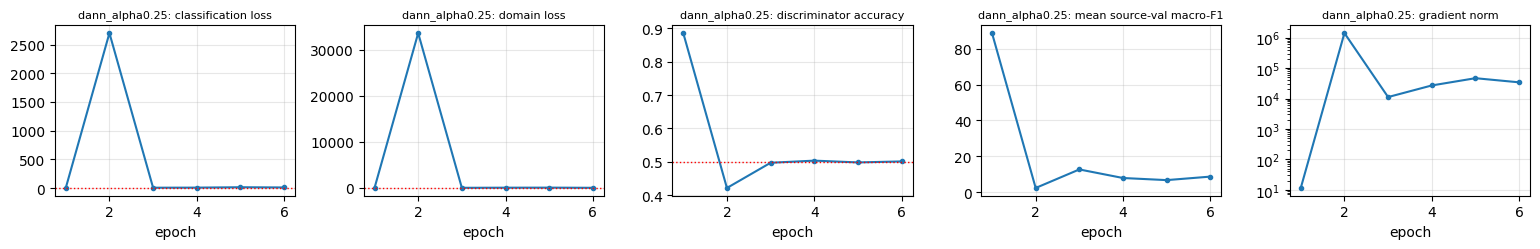

$ python -m task2.train --config task2/configs/study_dann_alpha0.5.yaml --set data_root=/content/data/PACS results_dir=task2/results/runs_clip0.0
[dann_alpha0.5] ep01 loss_cls=0.7395 loss_dom=5.9312 disc_acc=0.6768 alpha=0.0413 loss_total=6.6707 | val mean F1=44.74
[dann_alpha0.5] ep02 loss_cls=2.1438 loss_dom=14.8473 disc_acc=0.4789 alpha=0.1220 loss_total=16.9911 | val mean F1=5.96
[dann_alpha0.5] ep03 loss_cls=1.8872 loss_dom=0.7884 disc_acc=0.4886 alpha=0.1965 loss_total=2.6756 | val mean F1=28.01
[dann_alpha0.5] ep04 loss_cls=2.9672 loss_dom=5.7924 disc_acc=0.4508 alpha=0.2620 loss_total=8.7596 | val mean F1=5.99
[dann_alpha0.5] ep05 loss_cls=200.8512 loss_dom=824.7699 disc_acc=0.4996 alpha=0.3170 loss_total=1025.6211 | val mean F1=3.31
[dann_alpha0.5] ep06 loss_cls=11.9564 loss_dom=60.1147 disc_acc=0.5038 alpha=0.3617 loss_total=72.0710 | val mean F1=3.82
early stop at epoch 6 (best mean macro-F1 44.74)

=== dann_alpha0.5 ===
  grad_clip               : 0.0   (handout protocol: n

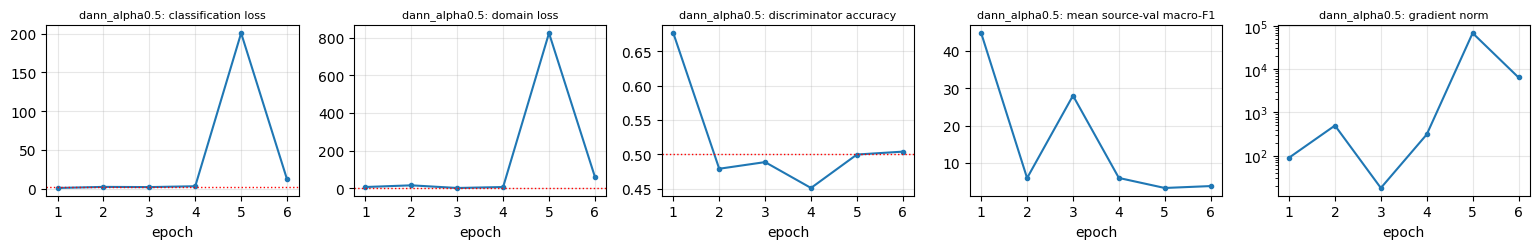

In [19]:
# B3. DIAGNOSTIC: DANN at reduced maximum alignment strength.
# alpha(p) keeps the same shape but saturates at 0.25 / 0.5 instead of 1.0.
# Same pipeline, same folders: these land in runs_clip0.0 alongside everything else.
for c, r in [('study_dann_alpha0.25', 'dann_alpha0.25'),
             ('study_dann_alpha0.5',  'dann_alpha0.5')]:
    if os.path.exists(f'{RUNS_DIR}/{r}/summary.json'):
        print(f'{r}: already finished -- skipping')
    else:
        run(f'python -m task2.train --config task2/configs/{c}.yaml {COMMON}')
    report(r)

## Part C — final evaluation (uses Sketch labels)

Reads `runs_clip0.0`, writes `final_clip0.0`. For each checkpoint: per-source-domain and Sketch
accuracy and macro-F1, the change versus Source-only, the domain-separability probe (frozen backbone,
equal numbers of source-validation and sketch features, balanced logistic regression at C = 1 on a
seed-6304 70/30 split; 50% = chance), then per-class accuracy, largest gain and drop, confusions and
failure images.

In [11]:
# C1. Evaluate this pipeline into its own output folder.
missing = [r for _, r in RUN_LIST if not os.path.exists(f'{RUNS_DIR}/{r}/summary.json')]
assert not missing, f'Unfinished runs: {missing}'
run(eval_cmd())
run(eval_cmd(STUDY))

main = pd.read_csv(f'{OUT_DIR}/table_main.csv')
base = main[main.method == 'source_only'].iloc[0]
print('\n================ MAIN COMPARISON (grad_clip = 0.0) ================')
print(f'Source-only domain gap: {base.mean_src_acc:.2f}% source-val vs {base.target_acc:.2f}% Sketch'
      f'  ->  {base.mean_src_acc - base.target_acc:.2f} points lost by changing domain.\n')
for _, r in main.iterrows():
    tag = 'baseline' if r.method == 'source_only' else f'{r.delta_target_acc:+.2f} pts vs baseline'
    print(f'  {r.method:12s} source-val {r.mean_src_f1:5.2f} F1 | Sketch {r.target_acc:5.2f}% acc, {r.target_f1:5.2f} F1 '
          f'| separability {r.domain_sep:5.2f}%  ({tag})')
print('\nRead the last two columns together: alignment only helps if lower separability comes with')
print('higher Sketch accuracy. Separability falling while Sketch accuracy drops is negative transfer.')

$ RUNS_DIR=task2/results/runs_clip0.0 OUT_DIR=task2/results/final_clip0.0 python -m task2.evaluate_final
     method  best_epoch  photo_acc  photo_f1  art_painting_acc  art_painting_f1  cartoon_acc  cartoon_f1  mean_src_acc  mean_src_f1  target_acc  target_f1  domain_sep  delta_target_acc
source_only          15      97.31     96.78             90.73            90.74        94.46       94.90         94.16        94.14       69.59      72.41       99.86              0.00
        dan          10      96.11     95.66             92.93            93.05        95.95       96.34         94.99        95.02       58.59      55.16       82.28            -11.00
       dann          18      52.10     41.11             29.27            26.83        46.70       37.17         42.69        35.04       26.44      18.91       98.08            -43.14
       cdan           1      94.01     92.92             82.68            83.09        88.70       90.23         88.46        88.75       58.49      58.74 

In [12]:
# C2. The controlled study.
study = pd.read_csv(f'{OUT_DIR}/table_study_{STUDY}.csv')
display(study.round(2))
print(f'Source-only reference: Sketch {base.target_acc:.2f}%, separability {base.domain_sep:.2f}%\n')
for _, r in study.iterrows():
    print(f'  {r.setting:12s} source-val {r.mean_src_f1:5.2f} F1 | separability {r.domain_sep:5.2f}% | Sketch {r.target_acc:5.2f}%')
print(f'\nChosen WITHOUT target labels (best source-val F1): {study.loc[study.mean_src_f1.idxmax()].setting}')
print(f'Best on Sketch, known only now                    : {study.loc[study.target_acc.idxmax()].setting}')
print('If those disagree, say so in RQ4: it shows the limits of label-free model selection.')

,setting,method,best_epoch,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_src_acc,mean_src_f1,target_acc,target_f1,domain_sep
0,lambda=0.1,dan_lambda0.1,8,97.90,97.47,89.51,89.51,94.03,94.73,93.82,93.90,67.01,63.50,97.25
1,lambda=1,dan,10,96.11,95.66,92.93,93.05,95.95,96.34,94.99,95.02,58.59,55.16,82.28
2,lambda=10,dan_lambda10,1,25.75,5.85,21.95,5.14,17.27,4.21,21.66,5.07,4.07,1.12,68.27


Source-only reference: Sketch 69.59%, separability 99.86%

  lambda=0.1   source-val 93.90 F1 | separability 97.25% | Sketch 67.01%
  lambda=1     source-val 95.02 F1 | separability 82.28% | Sketch 58.59%
  lambda=10    source-val  5.07 F1 | separability 68.27% | Sketch  4.07%

Chosen WITHOUT target labels (best source-val F1): lambda=1
Best on Sketch, known only now                    : lambda=0.1
If those disagree, say so in RQ4: it shows the limits of label-free model selection.


In [20]:
# C2b. The DANN alignment-strength study: alpha_max in {0.25, 0.5, 1}.
# The alpha=1 point is the diverged main DANN run, which is the comparison that matters.
run(eval_cmd('dann'))
dstudy = pd.read_csv(f'{OUT_DIR}/table_study_dann.csv')
display(dstudy.round(2))
print(f'Source-only reference: Sketch {base.target_acc:.2f}%, separability {base.domain_sep:.2f}%\n')
for _, r in dstudy.iterrows():
    print(f'  {r.setting:12s} source-val {r.mean_src_f1:5.2f} F1 | separability {r.domain_sep:5.2f}% | Sketch {r.target_acc:5.2f}%')

$ RUNS_DIR=task2/results/runs_clip0.0 OUT_DIR=task2/results/final_clip0.0 python -m task2.evaluate_final --study dann
       setting         method  best_epoch  photo_acc  photo_f1  art_painting_acc  art_painting_f1  cartoon_acc  cartoon_f1  mean_src_acc  mean_src_f1  target_acc  target_f1  domain_sep
alpha_max=0.25 dann_alpha0.25           1      94.61     93.57             81.46            82.35        89.13       90.34         88.40        88.75       52.30      52.70       99.73
 alpha_max=0.5  dann_alpha0.5           1      70.06     61.12             51.22            40.64        30.49       32.44         50.59        44.74       15.47       3.83      100.00
   alpha_max=1           dann          18      52.10     41.11             29.27            26.83        46.70       37.17         42.69        35.04       26.44      18.91       98.08


,setting,method,best_epoch,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_src_acc,mean_src_f1,target_acc,target_f1,domain_sep
0,alpha_max=0.25,dann_alpha0.25,1,94.61,93.57,81.46,82.35,89.13,90.34,88.40,88.75,52.30,52.70,99.73
1,alpha_max=0.5,dann_alpha0.5,1,70.06,61.12,51.22,40.64,30.49,32.44,50.59,44.74,15.47,3.83,100.00
2,alpha_max=1,dann,18,52.10,41.11,29.27,26.83,46.70,37.17,42.69,35.04,26.44,18.91,98.08


Source-only reference: Sketch 69.59%, separability 99.86%

  alpha_max=0.25 source-val 88.75 F1 | separability 99.73% | Sketch 52.30%
  alpha_max=0.5 source-val 44.74 F1 | separability 100.00% | Sketch 15.47%
  alpha_max=1  source-val 35.04 F1 | separability 98.08% | Sketch 26.44%


In [13]:
# C3. Per-class analysis: does the aggregate hide class-specific damage?
pc = pd.read_csv(f'{OUT_DIR}/per_class_target_acc.csv', index_col=0)
print('Per-class Sketch accuracy (%):'); display(pc.round(2))
print('Change vs Source-only (percentage points):')
display(pc.drop(columns=['source_only']).sub(pc['source_only'], axis=0).round(2))
ana = json.load(open(f'{OUT_DIR}/class_analysis.json'))
print(f'\nSource-only is weakest on "{ana["source_only_weakest_class"]}" -- its images go to:')
for c in ana['source_only_confusions'][ana['source_only_weakest_class']]:
    print(f'   -> {c["pred"]:9s} {c["count"]:4d} ({c["share_%"]:.1f}%)')
for m in [r for r in main.method if r != 'source_only']:
    g, d = ana[m]['largest_gain'], ana[m]['largest_drop']
    print(f'\n{m}:\n   biggest gain : {g["class"]:9s} {g["delta_pp"]:+.1f} pts'
          f'\n   biggest drop : {d["class"]:9s} {d["delta_pp"]:+.1f} pts -> now go to: '
          + ', '.join(f'{c["pred"]} ({c["share_%"]:.0f}%)' for c in d['confusions_after'][:2]))
print('\nSketch has only 80 house and 160 person images; quote those counts with the percentages.')

Per-class Sketch accuracy (%):


,source_only,dan,dann,cdan
dog,53.24,43.52,33.68,5.83
elephant,89.32,54.05,18.65,100.00
giraffe,45.29,61.62,58.17,34.53
guitar,83.39,78.62,0.82,85.86
horse,77.45,61.76,22.55,74.75
house,87.50,100.00,12.50,87.50
person,70.00,25.00,2.50,31.88


Change vs Source-only (percentage points):


,dan,dann,cdan
dog,-9.72,-19.56,-47.41
elephant,-35.27,-70.68,10.68
giraffe,16.33,12.88,-10.76
guitar,-4.77,-82.57,2.47
horse,-15.69,-54.90,-2.70
house,12.50,-75.00,0.00
person,-45.00,-67.50,-38.12



Source-only is weakest on "giraffe" -- its images go to:
   -> horse      154 (20.5%)
   -> dog        117 (15.5%)
   -> elephant    96 (12.7%)

dan:
   biggest gain : giraffe   +16.3 pts
   biggest drop : person    -45.0 pts -> now go to: house (75%)

dann:
   biggest gain : giraffe   +12.9 pts
   biggest drop : guitar    -82.6 pts -> now go to: giraffe (71%), elephant (18%)

cdan:
   biggest gain : elephant  +10.7 pts
   biggest drop : dog       -47.4 pts -> now go to: elephant (53%), horse (40%)

Sketch has only 80 house and 160 person images; quote those counts with the percentages.



--- failures_cdan_dog.png ---
Failure cases: right under Source-only, wrong after this method


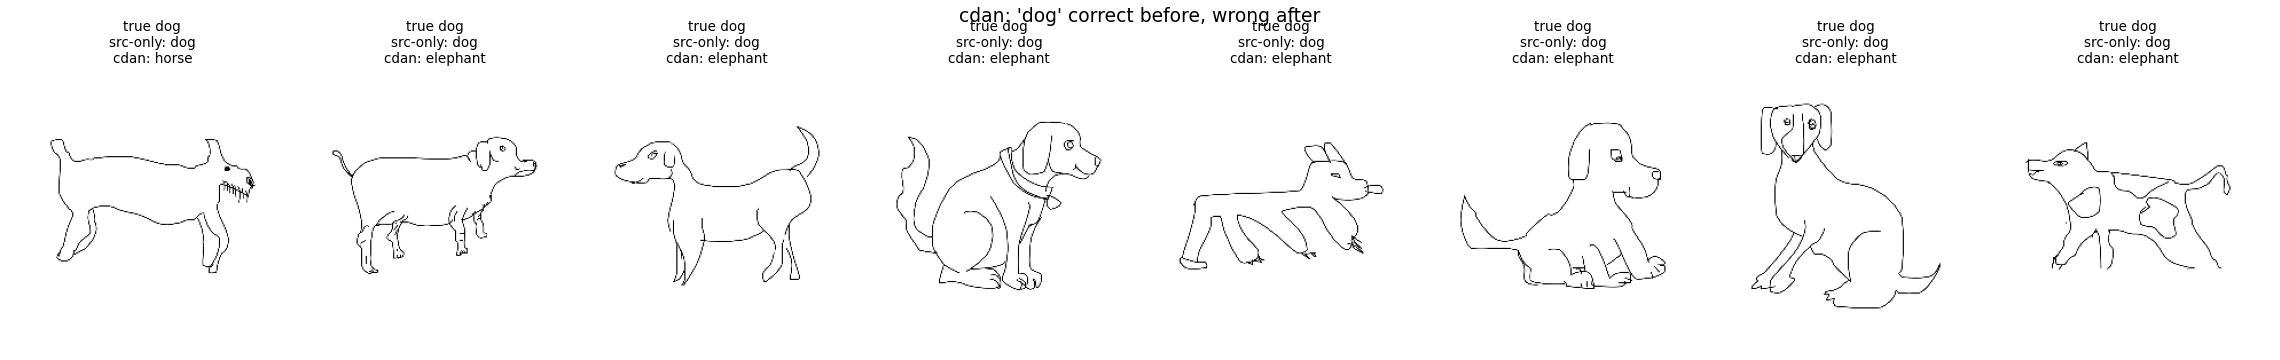


--- failures_dan_person.png ---
Failure cases: right under Source-only, wrong after this method


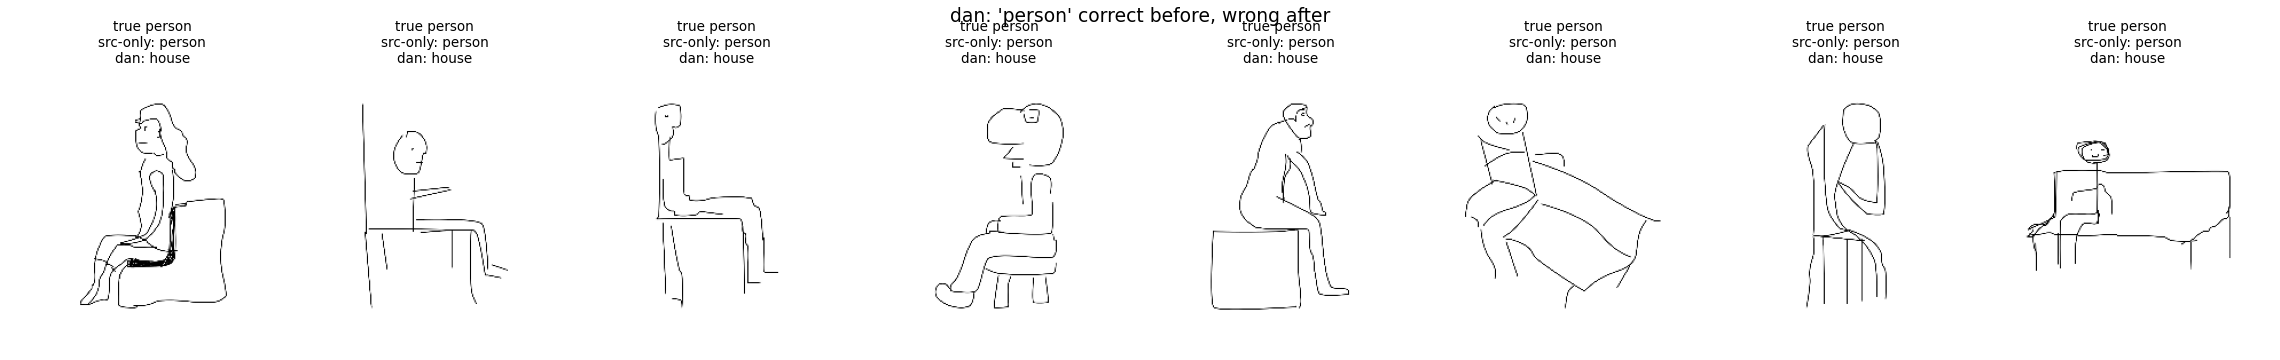


--- failures_dann_guitar.png ---
Failure cases: right under Source-only, wrong after this method


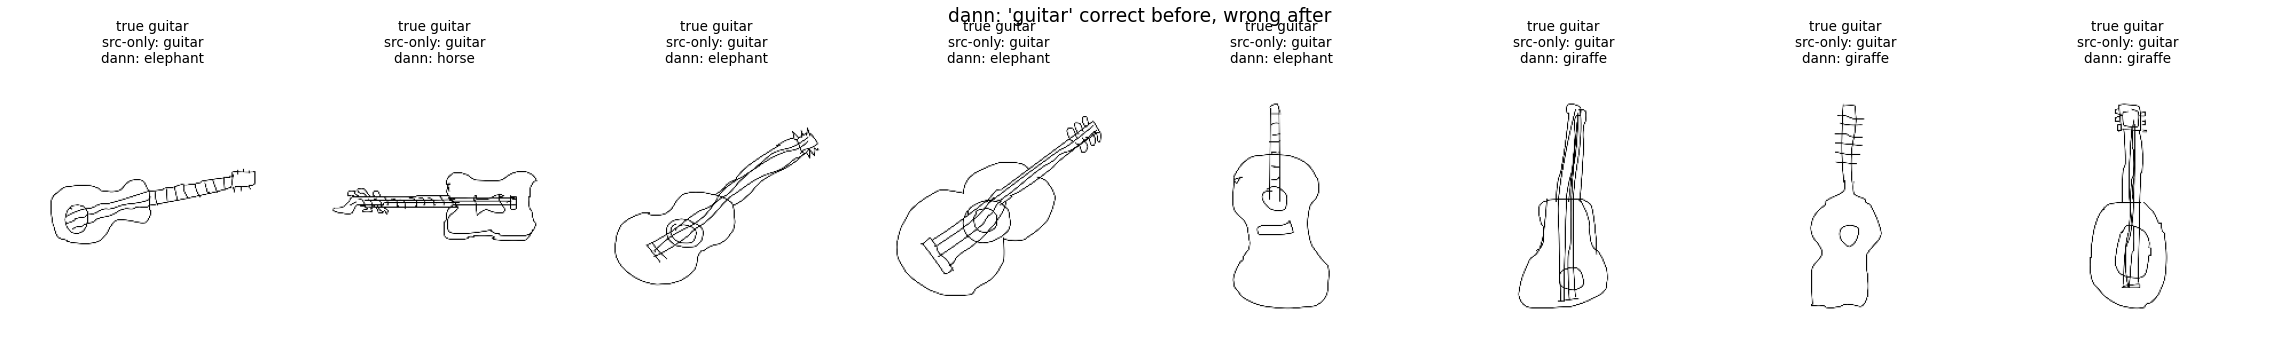


--- failures_source_only_giraffe.png ---
Failure cases: right under Source-only, wrong after this method


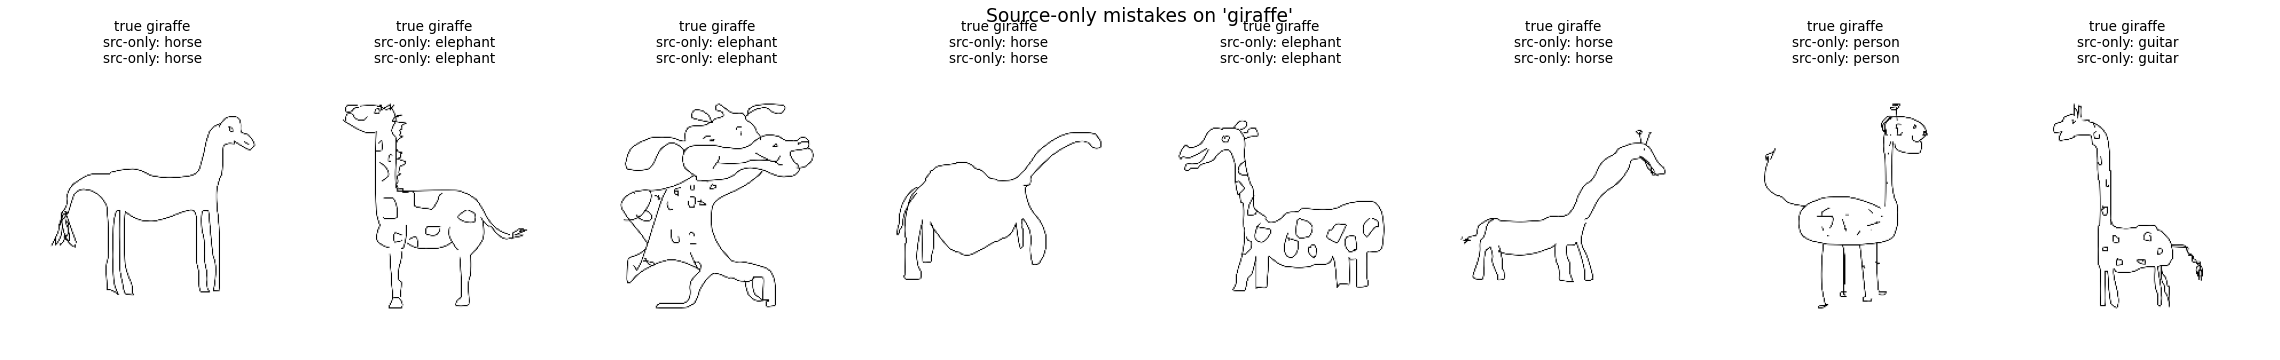


--- per_class_delta.png ---
Required: per-class Sketch accuracy change vs Source-only


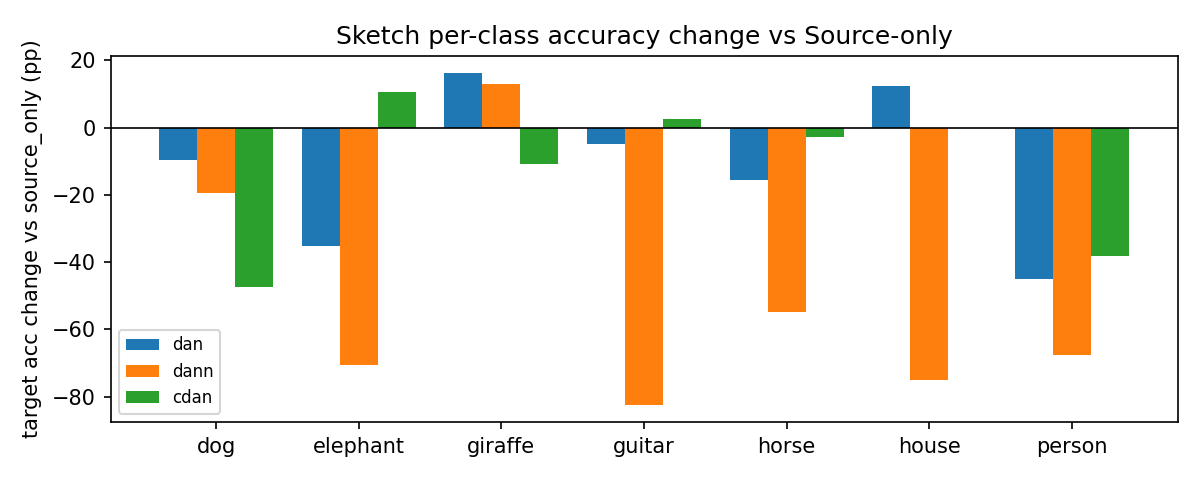


--- study_dan.png ---
Controlled study: source F1, separability and Sketch accuracy vs lambda


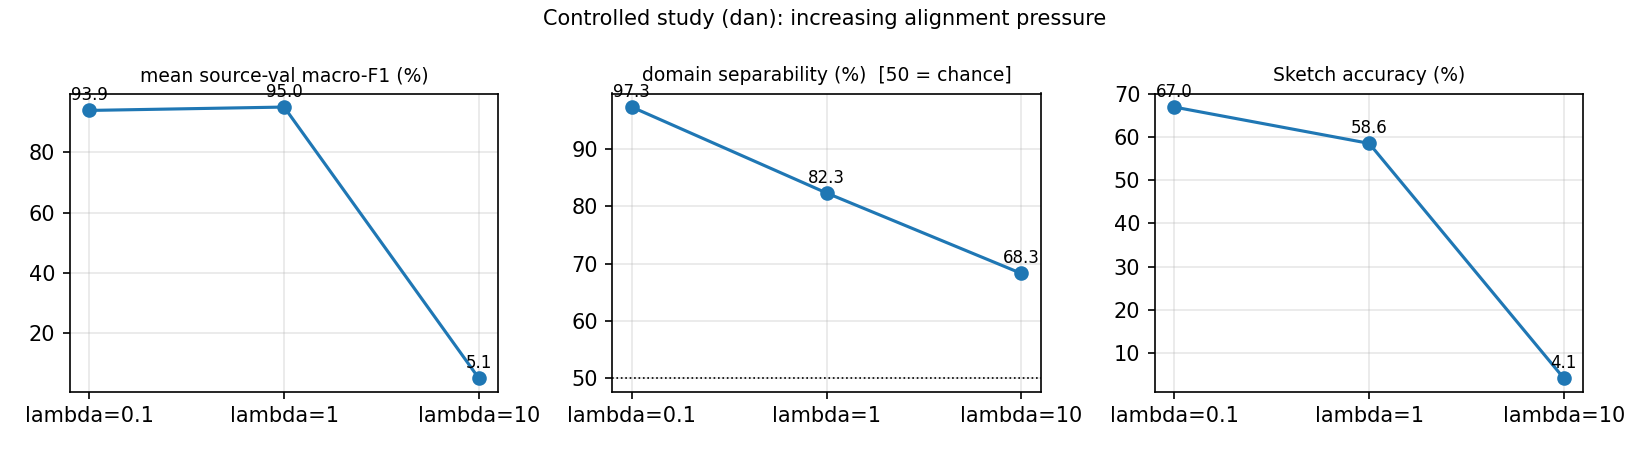


--- training_curves.png ---
Required: did each method train as intended?


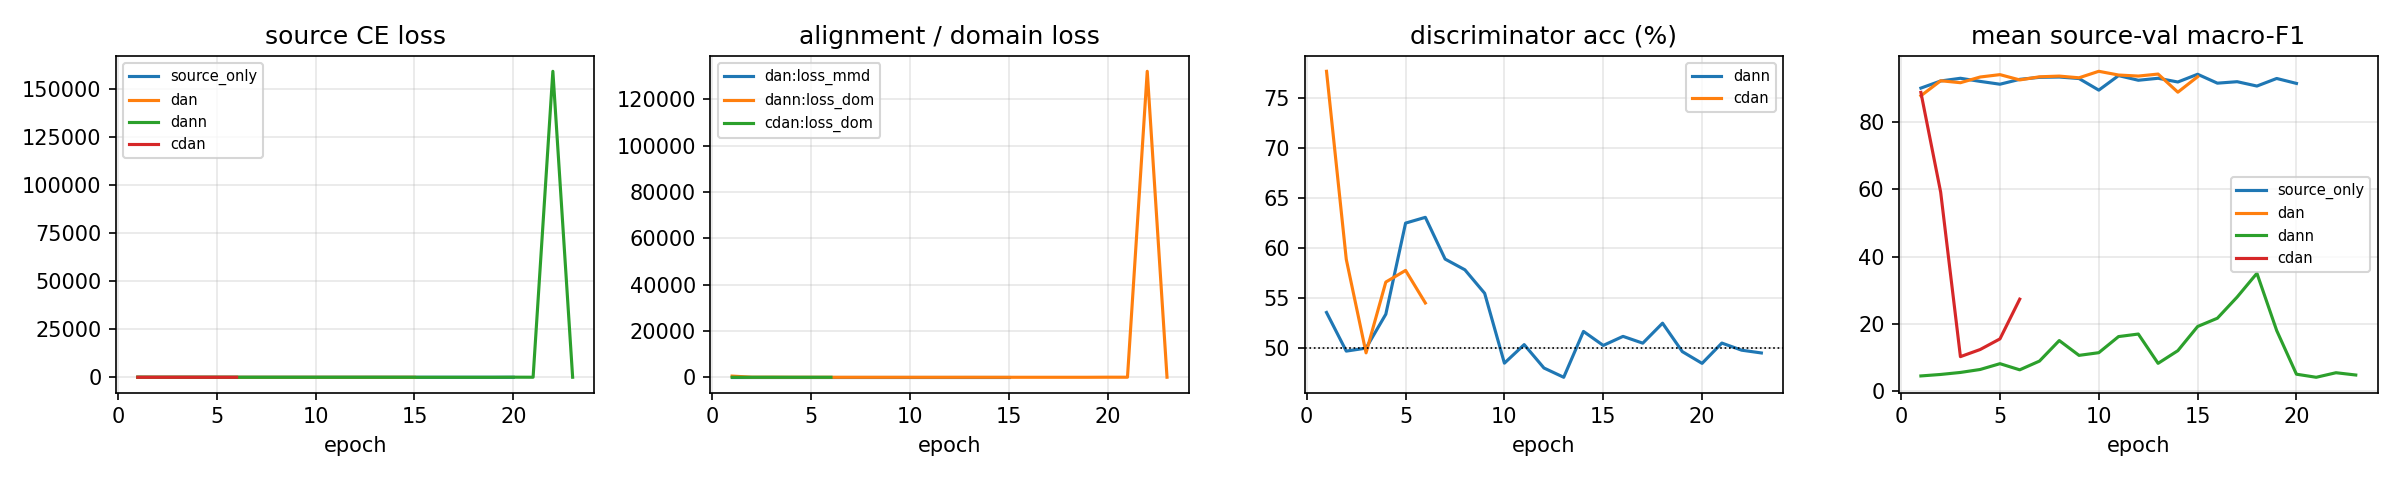


--- training_curves_study_dan.png ---
Curves for the study runs


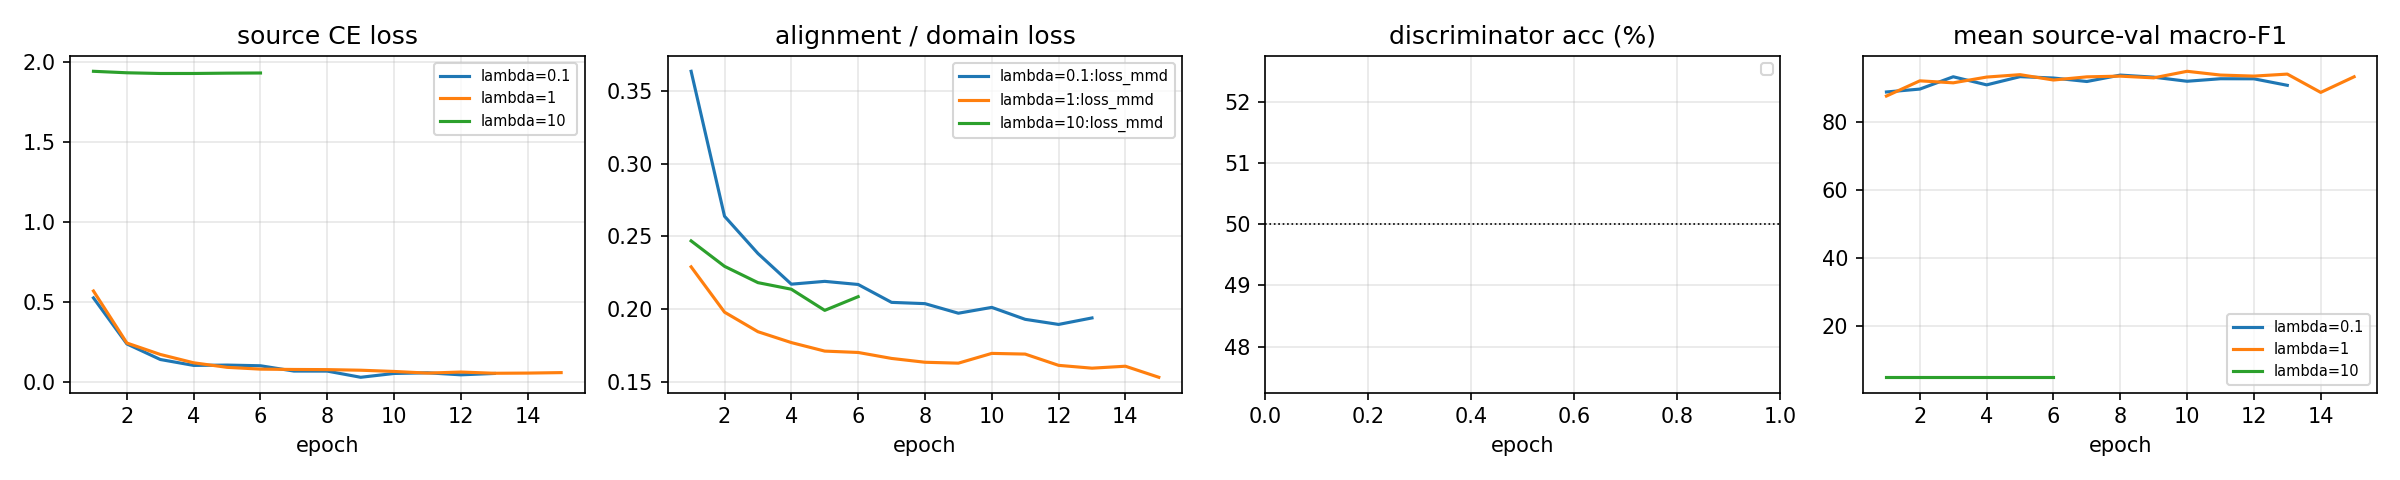

In [14]:
# C4. Figures for this pipeline.
from IPython.display import Image, display as show
CAPS = {'training_curves.png': 'Required: did each method train as intended?',
        'per_class_delta.png': 'Required: per-class Sketch accuracy change vs Source-only',
        'study_dan.png': 'Controlled study: source F1, separability and Sketch accuracy vs lambda',
        'training_curves_study_dan.png': 'Curves for the study runs'}
for q in sorted(glob.glob(f'{OUT_DIR}/figures/*.png')):
    n = os.path.basename(q)
    print(f'\n--- {n} ---\n' + CAPS.get(n, 'Failure cases: right under Source-only, wrong after this method'))
    show(Image(q))

In [15]:
# C5. Class shares per domain (analysis only; reads Sketch labels). Zhao et al. (2019): aligning
# domains whose class proportions differ raises a floor on the combined error.
import collections
from shared.pacs import CLASSES
counts = {d: collections.Counter(y for _, y in s['train'] + s['val']) for d, s in src.items()}
counts['sketch'] = collections.Counter(y for _, y in json.load(open('shared/splits/pacs_sketch_target.json'))['items'])
cnt = pd.DataFrame(counts).sort_index().rename(index=dict(enumerate(CLASSES)))
share = (100 * cnt / cnt.sum()).round(1)
print('Images per class:'); display(cnt)
print('Class share (%):'); display(share)
print('Sketch share minus average source share (pts):')
print((share['sketch'] - share[[c for c in share.columns if c != 'sketch']].mean(axis=1)).round(1).sort_values().to_string())

Images per class:


,photo,art_painting,cartoon,sketch
dog,189,379,389,772
elephant,202,255,457,740
giraffe,182,285,346,753
guitar,186,184,135,608
horse,199,201,324,816
house,280,295,288,80
person,432,449,405,160


Class share (%):


,photo,art_painting,cartoon,sketch
dog,11.3,18.5,16.6,19.6
elephant,12.1,12.5,19.5,18.8
giraffe,10.9,13.9,14.8,19.2
guitar,11.1,9.0,5.8,15.5
horse,11.9,9.8,13.8,20.8
house,16.8,14.4,12.3,2.0
person,25.9,21.9,17.3,4.1


Sketch share minus average source share (pts):
person     -17.6
house      -12.5
dog          4.1
elephant     4.1
giraffe      6.0
guitar       6.9
horse        9.0


In [16]:
# C6. Appendix table: the two pipelines side by side (read-only).
old = 'task2/results/final/table_main.csv'
if os.path.exists(old):
    a = pd.read_csv(old).set_index('method')[['mean_src_f1', 'target_acc', 'domain_sep']]
    b = main.set_index('method')[['mean_src_f1', 'target_acc', 'domain_sep']]
    display(a.join(b, lsuffix='_clip1.0', rsuffix='_clip0.0').round(2))
    print('Same code, splits and seed; the only difference is gradient clipping. Use this to show that')
    print('clipping shifted the baseline and still did not prevent the adversarial runs from diverging.')
else:
    print('No clipped results at', old, '-- skip this table.')

,mean_src_f1_clip1.0,target_acc_clip1.0,domain_sep_clip1.0,mean_src_f1_clip0.0,target_acc_clip0.0,domain_sep_clip0.0
method,,,,,,
source_only,93.88,65.33,99.86,94.14,69.59,99.86
dan,93.70,56.81,87.23,95.02,58.59,82.28
dann,77.51,43.73,99.86,35.04,26.44,98.08
cdan,93.39,20.18,98.90,88.75,58.49,99.45


Same code, splits and seed; the only difference is gradient clipping. Use this to show that
clipping shifted the baseline and still did not prevent the adversarial runs from diverging.


## Part D — hand-off

In [17]:
# D1. What Task 3 needs, now that ERM is not at the default path.
ERM = f'{RUNS_DIR}/source_only/best.pt'
assert os.path.exists(ERM), ERM
print('In the Task 3 notebook use:\n')
print(f"  COMMON  = f'--set data_root={{PACS}} erm_checkpoint={ERM}'        # every task3 command")
print(f"  ck      = '{ERM}'                                                  # cell A6")
print(f"  erm_cfg = load_json('{RUNS_DIR}/source_only/config_resolved.json')  # cell A6")
print('\nAnd leave grad_clip: 0.0 in task2/configs/base.yaml -- Task 3 inherits it and checks it.')

In the Task 3 notebook use:

  COMMON  = f'--set data_root={PACS} erm_checkpoint=task2/results/runs_clip0.0/source_only/best.pt'        # every task3 command
  ck      = 'task2/results/runs_clip0.0/source_only/best.pt'                                                  # cell A6
  erm_cfg = load_json('task2/results/runs_clip0.0/source_only/config_resolved.json')  # cell A6

And leave grad_clip: 0.0 in task2/configs/base.yaml -- Task 3 inherits it and checks it.


In [18]:
# D2. GitHub zip (checkpoints, data and caches excluded by .gitignore).
!rm -rf /tmp/gitcheck && git init -q /tmp/gitcheck
!git --git-dir=/tmp/gitcheck/.git --work-tree=. ls-files --others --exclude-standard > /tmp/commit_list.txt
print('files to commit:', len(open('/tmp/commit_list.txt').read().split()))
!du -ch $(cat /tmp/commit_list.txt) | tail -1
!rm -f "{DRIVE}/PA1_github.zip" && zip -q -@ "{DRIVE}/PA1_github.zip" < /tmp/commit_list.txt
print('Saved My Drive/PA1_github.zip  (both results folders included)')

files to commit: 157
28M	total
Saved My Drive/PA1_github.zip  (both results folders included)


## Troubleshooting
- **This notebook never moves or deletes anything.** If a cell errors, nothing is lost.
- **A6 shows the wrong `grad_clip` for a folder:** the two run folders are swapped. Check before Part C rather than renaming.
- **Re-evaluate the clipped runs later:** `RUNS_DIR=task2/results/runs_clip1.0 OUT_DIR=task2/results/final python -m task2.evaluate_final` (that is what produced the existing `final/`).
- **Redo one run:** delete only that folder inside `runs_clip0.0` and re-run cell B1.
- **A run is COLLAPSED or unstable:** expected for DANN and CDAN here; keep the curves as evidence.